# Đánh giá Mô hình Transformer + Focal Loss cho dữ liệu Poker Hand
Sử dụng các cấu trúc Transformer (Small, Medium, Big) kết hợp hàm mất mát Focal Loss để đánh giá hiệu quả của việc dự đoán Poker Hand trên dữ liệu gốc (RAW) và dữ liệu đã qua Feature Engineering (FE).
Đánh giá bao gồm: Confusion Matrix dạng hình ảnh, ROC-AUC, Thời gian chạy (Run time), F1-score, Recall, Precision.

In [55]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

## 1. Định nghĩa Focal Loss

In [56]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

## 2. Xây dựng cấu trúc mô hình Transformer

In [ ]:
class PokerTransformer(nn.Module):
    def __init__(self, num_classes=10, num_features=10, embed_dim=16, num_heads=2, num_layers=1, ff_dim=32, dropout=0.1, patch_size=5):
        super().__init__()
        # Split embed_dim: rank size is twice suit size, combined into embed_dim
        self.suit_dim = embed_dim // 3
        self.rank_dim = embed_dim - self.suit_dim
        
        # 4 suits (giá trị 1-4, index 0-3)
        self.suit_embedding = nn.Embedding(4, self.suit_dim)
        # 13 ranks (giá trị 1-13, index 0-12)
        self.rank_embedding = nn.Embedding(13, self.rank_dim)
        
        # 10 features corresponding to 5 cards (each having suit and rank)
        self.pos_encoder = nn.Parameter(torch.randn(1, 5, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dim_feedforward=ff_dim, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim * 5, num_classes)
        
    def forward(self, x):
        x_long = x.long()
        # Separate suits and ranks for 5 cards
        suits = x_long[:, 0::2] - 1  # 1-4 -> 0-3
        ranks = x_long[:, 1::2] - 1  # 1-13 -> 0-12
        
        suits = suits.clamp(0, 3)
        ranks = ranks.clamp(0, 12)
        
        suit_emb = self.suit_embedding(suits)  # (batch_size, 5, suit_dim)
        rank_emb = self.rank_embedding(ranks)  # (batch_size, 5, rank_dim)
        
        # Concatenate rank and suit embeddings into a single card representation
        card_emb = torch.cat([rank_emb, suit_emb], dim=-1)  # (batch_size, 5, embed_dim)
        
        x_emb = card_emb + self.pos_encoder
        x_trans = self.transformer(x_emb)
        x_flat = x_trans.reshape(x_trans.size(0), -1)
        logits = self.fc(x_flat)
        return logits

class TransformerSmall(nn.Module):
    def __init__(self, num_classes=10, num_features=10):
        super().__init__()
        self.model = PokerTransformer(
            num_classes=num_classes, num_features=num_features,
            embed_dim=24, num_heads=2, num_layers=3,
            ff_dim=64, dropout=0.1, patch_size=5
        )

    def forward(self, x):
        return self.model(x)

class TransformerMedium(nn.Module):
    def __init__(self, num_classes=10, num_features=10):
        super().__init__()
        self.num_features = num_features
        self.model = PokerTransformer(
            num_classes=num_classes, num_features=num_features,
            embed_dim=72, num_heads=4, num_layers=6,
            ff_dim=256, dropout=0.1, patch_size=7
        )

    def forward(self, x):
        return self.model(x)

class TransformerBig(nn.Module):
    def __init__(self, num_classes=10, num_features=10):
        super().__init__()
        self.model = PokerTransformer(
            num_classes=num_classes, num_features=num_features,
            embed_dim=96, num_heads=8, num_layers=12,
            ff_dim=512, dropout=0.1, patch_size=7
        )
    def forward(self, x):
        return self.model(x)

class TransformerBig2(nn.Module):
    def __init__(self, num_classes=10, num_features=10):
        super
        
        
        ().__init__()
        self.model = PokerTransformer(
            num_classes=num_classes, num_features=num_features,
            embed_dim=192, num_heads=12, num_layers=16,
            ff_dim=1024, dropout=0.1, patch_size=7
        )
        

    def forward(self, x):
        return self.model(x)

## 3. Khai báo hàm Load Dữ liệu và Huấn luyện/Đánh giá

In [58]:
def load_data(file_train, file_test):
    df_train = pd.read_csv(file_train)
    df_test = pd.read_csv(file_test)
    X_train = torch.tensor(df_train.drop('Class', axis=1).values, dtype=torch.long)
    y_train = torch.tensor(df_train['Class'].values, dtype=torch.long)
    X_test = torch.tensor(df_test.drop('Class', axis=1).values, dtype=torch.long)
    y_test = torch.tensor(df_test['Class'].values, dtype=torch.long)
    return X_train, y_train, X_test, y_test

def run_experiment(model_class, num_features, train_loader, test_loader, epochs=5, lr=0.001, title="Model"):
    print(f"========== Bắt đầu huấn luyện: {title} ==========")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model_class(num_classes=10, num_features=num_features).to(device)
    criterion = FocalLoss(gamma=2.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    start_time = time.time()
    
    # Training
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
    # Evaluation
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            probs = F.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
            
    run_time = time.time() - start_time
    print(f"Thời gian chạy (Train + Eval): {run_time:.2f} giây")
    
    # Metrics
    print("\n--- Classification Report ---")
    print(classification_report(all_targets, all_preds, zero_division=0))
    
    # ROC-AUC
    try:
        # Lọc ra các class thực sự xuất hiện trong y_true
        present_classes = np.unique(all_targets)
        y_prob_filtered = np.array(all_probs)[:, present_classes]
        # Normalize probabilities so they sum to 1 after filtering
        y_prob_filtered = y_prob_filtered / y_prob_filtered.sum(axis=1, keepdims=True)
        
        roc_auc = roc_auc_score(all_targets, y_prob_filtered, multi_class='ovo', average='macro', labels=present_classes)
        print(f"ROC-AUC Score (Macro): {roc_auc:.4f}")
    except Exception as e:
        print(f"Không thể tính ROC-AUC: {e}")
        
    # Confusion Matrix Visualization
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()
    
    print("\n")

## 4. Load Data

In [59]:
# Load Dữ liệu Gốc (RAW)
X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_data(r'C:\Code\PokerHandPredict\data\train.csv', r'C:\Code\PokerHandPredict\data\test.csv')
train_loader_raw = DataLoader(TensorDataset(X_train_raw, y_train_raw), batch_size=256, shuffle=True)
test_loader_raw = DataLoader(TensorDataset(X_test_raw, y_test_raw), batch_size=1024, shuffle=False)
train_loader_raw_big = DataLoader(TensorDataset(X_train_raw, y_train_raw), batch_size=128, shuffle=True)
num_features_raw = X_train_raw.shape[1]

# Load Dữ liệu Feature Engineering (FE)
X_train_fe, y_train_fe, X_test_fe, y_test_fe = load_data(r'C:\Code\PokerHandPredict\data\train_fe.csv', r'C:\Code\PokerHandPredict\data\test_fe.csv')
train_loader_fe = DataLoader(TensorDataset(X_train_fe, y_train_fe), batch_size=256, shuffle=True)
test_loader_fe = DataLoader(TensorDataset(X_test_fe, y_test_fe), batch_size=1024, shuffle=False)
train_loader_fe_big = DataLoader(TensorDataset(X_train_fe, y_train_fe), batch_size=128, shuffle=True)
num_features_fe = X_train_fe.shape[1]

## 5. Chạy thực nghiệm trên Dữ liệu RAW

========== Bắt đầu huấn luyện: Transformer Small (RAW) ==========
Thời gian chạy (Train + Eval): 55.38 giây

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.97      0.93    501209
           1       0.91      0.87      0.89    422498
           2       0.63      0.60      0.61     47622
           3       0.33      0.03      0.06     21121
           4       0.30      0.01      0.02      3885
           5       0.33      0.00      0.00      1996
           6       0.61      0.18      0.28      1424
           7       0.00      0.00      0.00       230
           8       0.00      0.00      0.00        12
           9       0.00      0.00      0.00         3

    accuracy                           0.89   1000000
   macro avg       0.40      0.27      0.28   1000000
weighted avg       0.87      0.89      0.87   1000000

ROC-AUC Score (Macro): 0.8378


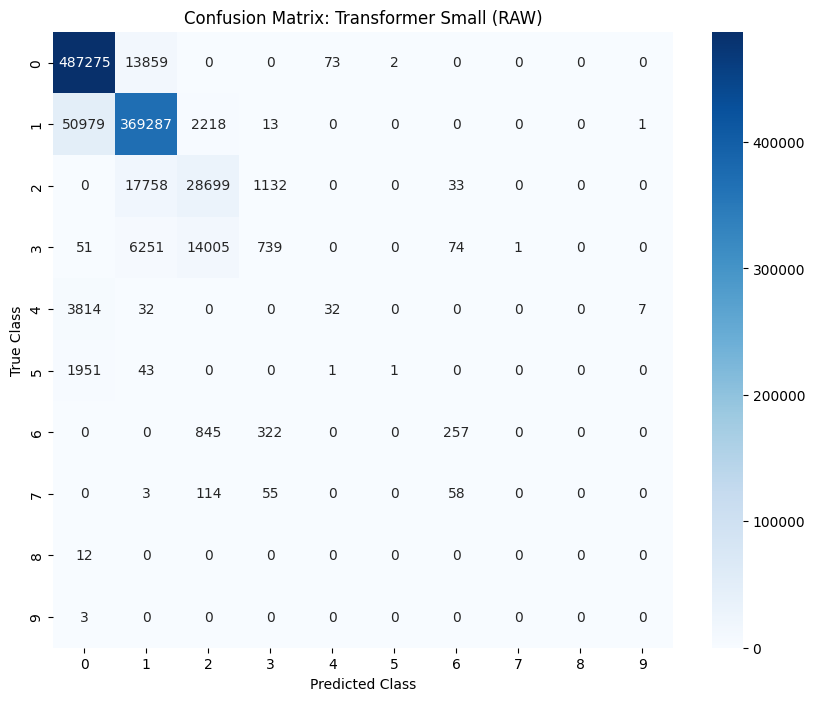

In [60]:
run_experiment(TransformerSmall, num_features_raw, train_loader_raw, test_loader_raw, epochs=100, lr=0.0005, title="Transformer Small (RAW)")

========== Bắt đầu huấn luyện: Transformer Medium (RAW) ==========
Thời gian chạy (Train + Eval): 416.33 giây

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    501209
           1       1.00      1.00      1.00    422498
           2       1.00      1.00      1.00     47622
           3       1.00      1.00      1.00     21121
           4       1.00      0.99      1.00      3885
           5       1.00      1.00      1.00      1996
           6       1.00      1.00      1.00      1424
           7       1.00      0.14      0.25       230
           8       1.00      0.83      0.91        12
           9       0.60      1.00      0.75         3

    accuracy                           1.00   1000000
   macro avg       0.96      0.90      0.89   1000000
weighted avg       1.00      1.00      1.00   1000000

ROC-AUC Score (Macro): 0.9985


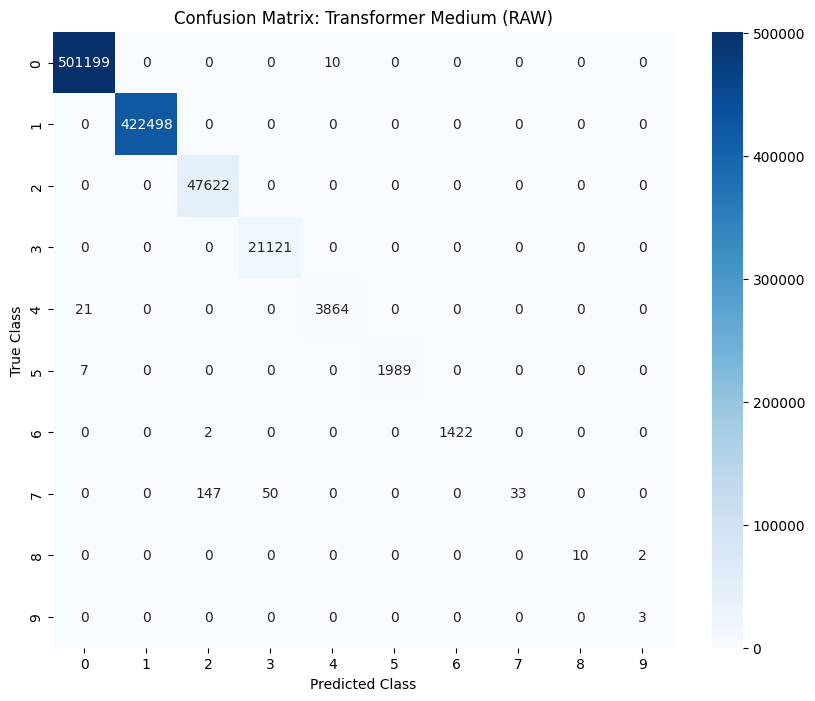

In [61]:
run_experiment(TransformerMedium, num_features_raw, train_loader_raw, test_loader_raw, epochs=200, lr=0.0005, title="Transformer Medium (RAW)")

========== Bắt đầu huấn luyện: Transformer Big (RAW) ==========
Thời gian chạy (Train + Eval): 4159.48 giây

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    501209
           1       1.00      1.00      1.00    422498
           2       1.00      1.00      1.00     47622
           3       1.00      1.00      1.00     21121
           4       0.99      0.96      0.98      3885
           5       1.00      0.98      0.99      1996
           6       1.00      1.00      1.00      1424
           7       1.00      0.49      0.65       230
           8       0.86      1.00      0.92        12
           9       0.75      1.00      0.86         3

    accuracy                           1.00   1000000
   macro avg       0.96      0.94      0.94   1000000
weighted avg       1.00      1.00      1.00   1000000

ROC-AUC Score (Macro): 0.9996


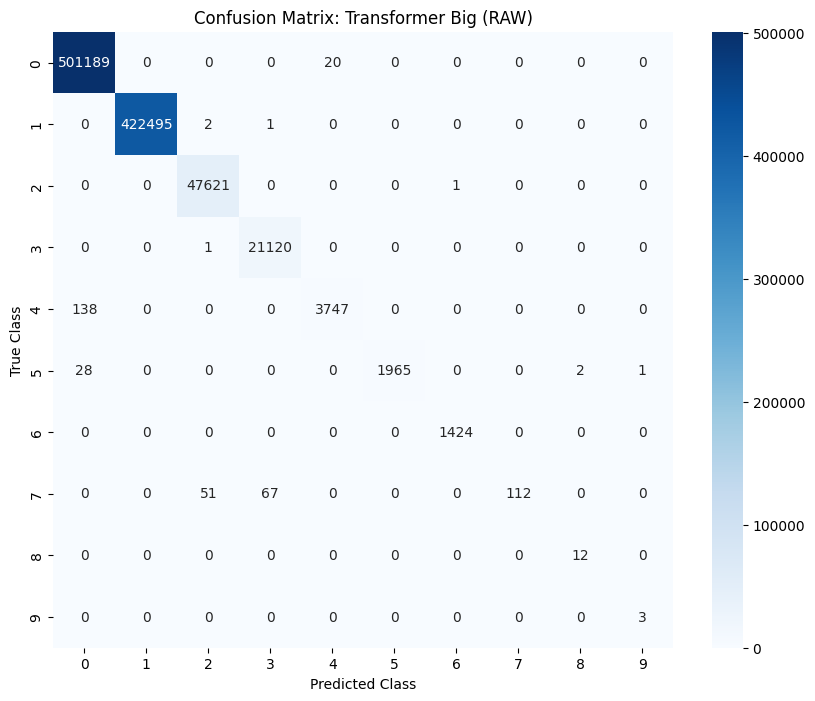

In [62]:
run_experiment(TransformerBig, num_features_raw, train_loader_raw_big, test_loader_raw, epochs=400, lr=0.0001, title="Transformer Big (RAW)")

## 6. Chạy thực nghiệm trên Dữ liệu FE

========== Bắt đầu huấn luyện: Transformer Small (FE) ==========
Thời gian chạy (Train + Eval): 118.44 giây

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00    501209
           1       1.00      1.00      1.00    422498
           2       1.00      1.00      1.00     47622
           3       1.00      1.00      1.00     21121
           4       0.58      0.20      0.30      3885
           5       0.98      0.98      0.98      1996
           6       1.00      1.00      1.00      1424
           7       1.00      0.74      0.85       230
           8       0.00      0.00      0.00        12
           9       0.20      1.00      0.33         3

    accuracy                           1.00   1000000
   macro avg       0.78      0.79      0.75   1000000
weighted avg       1.00      1.00      1.00   1000000

ROC-AUC Score (Macro): 0.9882


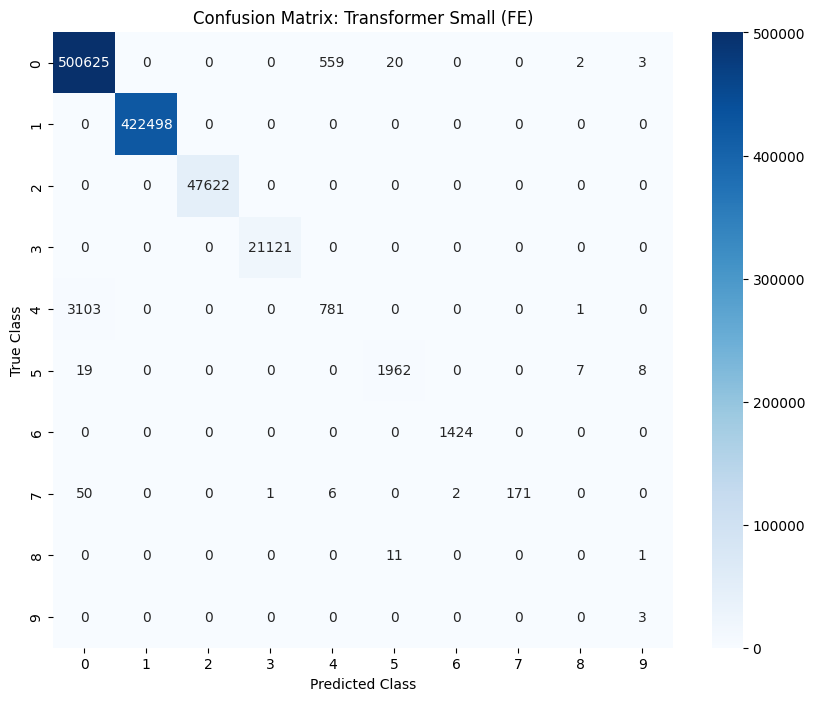

In [63]:
run_experiment(TransformerSmall, num_features_fe, train_loader_fe, test_loader_fe, epochs=100, lr=0.001, title="Transformer Small (FE)")

========== Bắt đầu huấn luyện: Transformer Medium (FE) ==========
Thời gian chạy (Train + Eval): 458.30 giây

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    501209
           1       1.00      1.00      1.00    422498
           2       1.00      1.00      1.00     47622
           3       1.00      1.00      1.00     21121
           4       0.99      0.90      0.94      3885
           5       1.00      1.00      1.00      1996
           6       1.00      1.00      1.00      1424
           7       1.00      0.95      0.98       230
           8       0.70      0.58      0.64        12
           9       0.38      1.00      0.55         3

    accuracy                           1.00   1000000
   macro avg       0.91      0.94      0.91   1000000
weighted avg       1.00      1.00      1.00   1000000

ROC-AUC Score (Macro): 0.9997


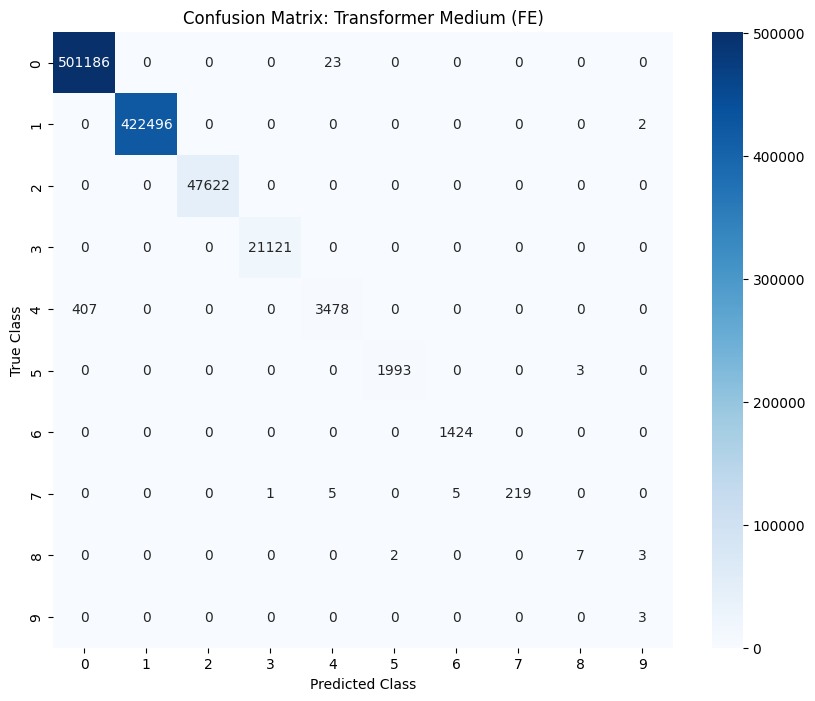

In [64]:
run_experiment(TransformerMedium, num_features_fe, train_loader_fe, test_loader_fe, epochs=200, lr=0.0005, title="Transformer Medium (FE)")